In [1]:
%cd ../
import awswrangler as wr
from wag_toolkit.locations import Locations
import pandas as pd
import json
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

/Users/delapazm/Desktop/wellcome_academic_graph_toolkit


/Users/delapazm/Desktop/wellcome_academic_graph_toolkit/venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


True

### Wellcome

In [ ]:
countries_class = pd.read_excel('geographies/files/CLASS.xlsx', sheet_name='List of economies')
lmic_list = countries_class[countries_class['Income group'].isin(['Low income', 'Lower middle income', 'Upper middle income'])]
lmic_list['Economy'] = lmic_list['Economy'].replace("Côte d’Ivoire", "Ivory Coast")
lmic_list['Economy'] = lmic_list['Economy'].replace("Gambia, The", "Gambia")
lmic_list['Economy'] = lmic_list['Economy'].replace("Iran, Islamic Rep.", "Iran")
lmic_list['Economy'] = lmic_list['Economy'].replace("Congo, Dem. Rep.", "Democratic Republic of the Congo")

/var/folders/dy/p3vg7l610wx7yc4y2908psy00000gp/T/ipykernel_96549/2822603552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lmic_list['Economy'] = lmic_list['Economy'].replace("Côte d’Ivoire", "Ivory Coast")
/var/folders/dy/p3vg7l610wx7yc4y2908psy00000gp/T/ipykernel_96549/2822603552.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lmic_list['Economy'] = lmic_list['Economy'].replace("Gambia, The", "Gambia")
/var/folders/dy/p3vg7l610wx7yc4y2908psy00000gp/T/ipykernel_96549/2822603552.py:5: SettingWithCo

In [3]:
dummy_query = """MATCH (r:Researcher)-[a:AUTHORED]->(p:Publication) RETURN * LIMIT 1"""
query = """MATCH (r:Researcher)-[a:AUTHORED]->(p:Publication)
            WHERE p.dimensions_publication_id IN {}
            RETURN p.dimensions_publication_id AS dimensions_publication_id, p.year AS year,
                a.institutions AS grid_id"""

In [ ]:
# wt_ch = wr.s3.read_excel('s3://datalabs-data/funding_impact_measures/climate_and_health/C&HPublicationExtraction.xlsx', sheet_name='Combined Awards')
# grants_ref = wr.s3.read_excel('s3://datalabs-data/funding_impact_measures/climate_and_health/Manual Tagging of Grants with C&H goals.xlsx', sheet_name='Total C&H Awards_SM tagging')
# grants_ref = grants_ref[grants_ref['C&H/C&H in partnership/wider portfolio (new)'].isin(['C&H', 'C&H in partnership'])]

grants_ref = pd.read_csv('geographies/files/Phase 2 Master Tagging Spreadsheet(GRANTS - Tagging).csv',
                         encoding='latin1')
grants_ids = list(set(grants_ref['Grant Reference'].to_list()))
# wt_ch = wt_ch[wt_ch['Wellcome Grant Reference'].isin(grants_list)]
# wt_pub_ids = list(set(wt_ch['Publication ID'].tolist()))

In [ ]:
# Uncomment for non-Wellcome funded publications

# all_ch = wr.s3.read_parquet('s3://datalabs-data/funding_impact_measures/climate_and_health/climate_health_intersection_just_ids.parquet')
# all_pub_ids = list(set(all_ch['publication_id'].tolist()))
# wt_pub_ids = list(set(all_pub_ids)-set(wt_pub_ids))

In [7]:
from dotenv import load_dotenv
import neo4j
import os

# Load environment variables from .env file
load_dotenv()

driver = neo4j.GraphDatabase.driver(
    os.environ["NEO4J_BOLT_URL"],
    auth=(os.environ["NEO4J_USERNAME"], os.environ["NEO4J_PASSWORD"]),
)

query = """MATCH (g:Grant)-[LINKED_TO]->(p:Publication) WHERE g.original_source_id IN $grant_ids 
           RETURN g.original_source_id as grant_reference, p.dimensions_publication_id as publication_id"""

with driver.session() as session:
    result = session.run(query, grant_ids=grants_ids)  # Correctly pass the list
    id_grants_df = pd.DataFrame([dict(record) for record in result])

id_grants_df.head()

,grant_reference,publication_id
0,219622/Z/19/Z,pub.1149152302
1,219622/Z/19/Z,pub.1152015571
2,219622/Z/19/Z,pub.1150059899
3,219622/Z/19/Z,pub.1148976221
4,219622/Z/19/Z,pub.1155893525


In [9]:
dummy_query = """MATCH (r:Researcher)-[a:AUTHORED]->(p:Publication) RETURN * LIMIT 1"""
loc = Locations(dummy_query)

pub_ids = list(set(id_grants_df['publication_id'].to_list()))

query = """MATCH (r:Researcher)-[a:AUTHORED]->(p:Publication)
            WHERE p.dimensions_publication_id IN {}
            RETURN p.dimensions_publication_id AS dimensions_publication_id, p.year AS year,
                a.institutions AS grid_id"""
loc.lookup_query(query=query, lookup=pub_ids)

data =pd.DataFrame(loc.data)
data = data.explode("grid_id").dropna()
data.head()

100%|██████████| 1/1 [00:01<00:00,  1.51s/it]


,dimensions_publication_id,year,grid_id
0,pub.1143316090,2021.0,grid.264727.2
1,pub.1143316090,2021.0,['grid.7836.a']
2,pub.1143316090,2021.0,grid.301713.7
3,pub.1143316090,2021.0,grid.7836.a
4,pub.1143316090,2021.0,grid.4714.6


In [10]:
from wag_toolkit.utils import Neo4j

neo4j = Neo4j()

unique_grid_ids = list(data['grid_id'].unique())
query = f"""
MATCH (i:Institution)
WHERE i.grid_id IN {unique_grid_ids}
RETURN i.grid_id as grid_id, i.country as country
"""
neo4j.query(query, as_graph=False)
countries_df = pd.DataFrame(neo4j.data)

100%|██████████| 1/1 [00:00<00:00,  1.80it/s]


In [11]:
merged_data = pd.merge(data, countries_df, on='grid_id', how='left')
merged_data['country'] = merged_data['country'].str.strip("[']")
merged_data.drop_duplicates(ignore_index=True, inplace=True)
merged_data

,dimensions_publication_id,year,grid_id,country
0,pub.1143316090,2021.0,grid.264727.2,United States
1,pub.1143316090,2021.0,['grid.7836.a'],NaN
2,pub.1143316090,2021.0,grid.301713.7,United Kingdom
3,pub.1143316090,2021.0,grid.7836.a,South Africa
4,pub.1143316090,2021.0,grid.4714.6,Sweden
...,...,...,...,...
5283,pub.1146942752,2022.0,grid.21107.35,United States
5284,pub.1129670019,2020.0,grid.8991.9,United Kingdom
5285,pub.1129670019,2020.0,grid.410759.e,Singapore
5286,pub.1154432791,2023.0,grid.7445.2,United Kingdom


In [12]:
pubs_data = {}

for publication in merged_data.dimensions_publication_id.unique():
    df = merged_data[merged_data['dimensions_publication_id'] == publication]
    
    if not df.empty and 'year' in df.columns:
        year_value = df['year'].iloc[0] 
        
        if year_value not in pubs_data:
            pubs_data[year_value] = {'cross-country': 0, 'lmic': 0, 'total': 0}
        
        # Check if there are multiple unique countries
        if len(df['country'].unique()) > 1:
            pubs_data[year_value]['cross-country'] += 1
        
        # Check if any country in the publication is in the lmic_list
        if set(df['country'].unique()) & set(lmic_list['Economy']):
            pubs_data[year_value]['lmic'] += 1
        
        pubs_data[year_value]['total'] += 1
    else:
        print(f"Skipping publication {publication} due to missing 'year' data.")


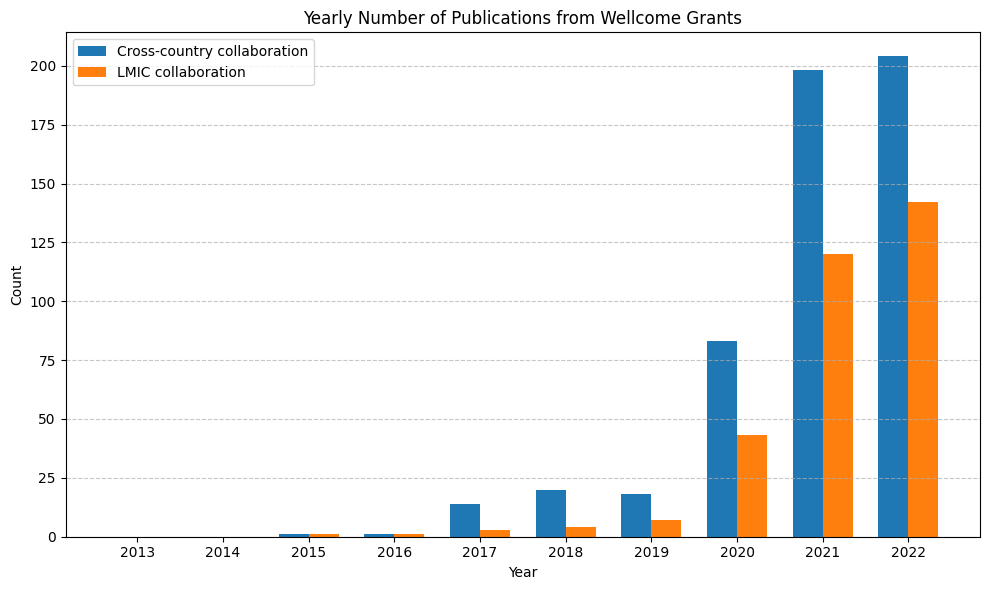

In [13]:
import matplotlib.pyplot as plt
import numpy as np


# Extract years and data for plotting
years = sorted(pubs_data.keys())[:-1]  
years_int = [int(year) for year in years] 
cross_country = [pubs_data[year]['cross-country'] for year in years]
lmic = [pubs_data[year]['lmic'] for year in years]
total = [pubs_data[year]['total'] for year in years]

# Calculate the ratio of 'lmic' to 'total'
lmic_to_total_ratio = [pubs_data[year]['lmic'] / pubs_data[year]['total'] for year in years]
cross_country_to_total_ratio = [pubs_data[year]['cross-country'] / pubs_data[year]['total'] for year in years]


bar_width = 0.35
x = np.arange(len(years))
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(x - bar_width / 2, cross_country, bar_width, label='Cross-country collaboration')
ax1.bar(x + bar_width / 2, lmic, bar_width, label='LMIC collaboration')
ax1.set_xlabel('Year')
ax1.set_ylabel('Count')
ax1.set_title('Yearly Number of Publications from Wellcome Grants')
ax1.set_xticks(x)
ax1.set_xticklabels(years_int)  
ax1.legend()
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# ax2 = ax1.twinx()  
# ax2.plot(x, lmic_to_total_ratio, color='purple', marker='o', label='Proportion of LMIC collaboration', linewidth=2)
# ax2.plot(x, cross_country_to_total_ratio, color='blue', marker='o', label='Proportion of cross-country collaboration', linewidth=2)
# ax2.set_ylabel('Publication Ratio')
# ax2.set_ylim(0,1)
# ax2.legend()

plt.tight_layout()
plt.show()

In [15]:
import csv
import json

csv_filename = 'countries_coordinates.csv'

json_path = '/Users/delapazm/Desktop/wellcome_academic_graph_toolkit/geographies/positions.json'
with open(json_path, 'r') as f:
    positions = json.load(f)

# Write to CSV using the csv module
with open(csv_filename, mode='w', newline='') as csv_file:
    fieldnames = ['Country', 'x', 'y']
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)

    writer.writeheader()
    for country, coordinates in positions.items():
        row = {'Country': country, 'x': coordinates['x'], 'y': coordinates['y']}
        writer.writerow(row)

print(f"CSV file '{csv_filename}' created successfully.")

CSV file 'countries_coordinates.csv' created successfully.


## Tableau map

In [95]:
import json

with open('ID_All_Countries/dict_edges_all.json', 'r') as f:
    dict_edges_all = json.load(f)

dict_edges_all_2022 = dict_edges_all['2022']
dict_edges_all_2021 = dict_edges_all['2021']
dict_edges_all_2020 = dict_edges_all['2020']
dict_edges_all_2019 = dict_edges_all['2019']
dict_edges_all_2018 = dict_edges_all['2018']    
dict_edges_all_2017 = dict_edges_all['2017']    
dict_edges_all_2016 = dict_edges_all['2016']
dict_edges_all_2015 = dict_edges_all['2015']

In [96]:
df_edges_2022 = pd.DataFrame(dict_edges_all_2022)[['from', 'to', 'width']]
df_edges_2021 = pd.DataFrame(dict_edges_all_2021)[['from', 'to', 'width']]
df_edges_2020 = pd.DataFrame(dict_edges_all_2020)[['from', 'to', 'width']]
df_edges_2019 = pd.DataFrame(dict_edges_all_2019)[['from', 'to', 'width']]
df_edges_2018 = pd.DataFrame(dict_edges_all_2018)[['from', 'to', 'width']]
df_edges_2017 = pd.DataFrame(dict_edges_all_2017)[['from', 'to', 'width']]
df_edges_2016 = pd.DataFrame(dict_edges_all_2016)[['from', 'to', 'width']]
df_edges_2015 = pd.DataFrame(dict_edges_all_2015)[['from', 'to', 'width']]

In [97]:
df_edges_2022.head()

,from,to,width
0,Algeria,Angola,0.35
1,Algeria,Belgium,0.15
2,Algeria,Botswana,1.95
3,Algeria,Burkina Faso,0.45
4,Algeria,Burundi,0.25


In [98]:
coordinates = pd.read_csv('geographies/countries.csv')
coordinates.head()

,country,latitude,longitude,name
0,AD,42.546245,1.601554,Andorra
1,AE,23.424076,53.847818,United Arab Emirates
2,AF,33.939110,67.709953,Afghanistan
3,AG,17.060816,-61.796428,Antigua and Barbuda
4,AI,18.220554,-63.068615,Anguilla


In [99]:
dfs = [df_edges_2022, df_edges_2021, df_edges_2020, df_edges_2019, df_edges_2018, df_edges_2017, df_edges_2016, df_edges_2015]

# Loop through each dataframe in dfs
for idx, df in enumerate(dfs):
    # Merge the 'from' and 'to' country names with the coordinates DataFrame to get the coordinates
    df = pd.merge(df, coordinates, how='left', left_on='from', right_on='name', suffixes=('', '_from'))
    df = pd.merge(df, coordinates, how='left', left_on='to', right_on='name', suffixes=('', '_to'))

    # Rename the columns as needed
    df['from_x'] = df['latitude']
    df['from_y'] = df['longitude']
    df['to_x'] = df['latitude_to']
    df['to_y'] = df['longitude_to']
    
    # Drop unnecessary columns
    df = df[['from', 'from_x', 'from_y', 'to', 'to_x', 'to_y', 'width']]
    
    # Update the dataframe in the list with the modified one
    dfs[idx] = df

# Now `df_edges_2022` (and other dataframes in `dfs`) will have the updated columns
df_edges_2022 = dfs[0]
df_edges_2021 = dfs[1]
df_edges_2020 = dfs[2]
df_edges_2019 = dfs[3]
df_edges_2018 = dfs[4]
df_edges_2017 = dfs[5]
df_edges_2016 = dfs[6]
df_edges_2015 = dfs[7]


In [100]:
df_edges_2022.head()

,from,from_x,from_y,to,to_x,to_y,width
0,Algeria,28.033886,1.659626,Angola,-11.202692,17.873887,0.35
1,Algeria,28.033886,1.659626,Belgium,50.503887,4.469936,0.15
2,Algeria,28.033886,1.659626,Botswana,-22.328474,24.684866,1.95
3,Algeria,28.033886,1.659626,Burkina Faso,12.238333,-1.561593,0.45
4,Algeria,28.033886,1.659626,Burundi,-3.373056,29.918886,0.25


In [101]:
df_edges_2022.to_csv('ID_All_Countries/edges_2022.csv', index=False)
df_edges_2021.to_csv('ID_All_Countries/edges_2021.csv', index=False)       
df_edges_2020.to_csv('ID_All_Countries/edges_2020.csv', index=False)
df_edges_2019.to_csv('ID_All_Countries/edges_2019.csv', index=False)
df_edges_2018.to_csv('ID_All_Countries/edges_2018.csv', index=False)
df_edges_2017.to_csv('ID_All_Countries/edges_2017.csv', index=False)
df_edges_2016.to_csv('ID_All_Countries/edges_2016.csv', index=False)
df_edges_2015.to_csv('ID_All_Countries/edges_2015.csv', index=False)

In [102]:
# Add a 'year' column to each DataFrame in dfs
for idx, df in enumerate(dfs):
    # Add the 'year' column based on the DataFrame index
    df['year'] = 2022 - idx  # Starting from 2022 down to 2015
    
# Concatenate all DataFrames in dfs into a single DataFrame
big_df = pd.concat(dfs, ignore_index=True)

# Display the first few rows of the combined DataFrame
big_df.head()


,from,from_x,from_y,to,to_x,to_y,width,year
0,Algeria,28.033886,1.659626,Angola,-11.202692,17.873887,0.35,2022
1,Algeria,28.033886,1.659626,Belgium,50.503887,4.469936,0.15,2022
2,Algeria,28.033886,1.659626,Botswana,-22.328474,24.684866,1.95,2022
3,Algeria,28.033886,1.659626,Burkina Faso,12.238333,-1.561593,0.45,2022
4,Algeria,28.033886,1.659626,Burundi,-3.373056,29.918886,0.25,2022


In [103]:
big_df.to_csv('ID_All_Countries/edges_all_years_no_missing.csv', index=False)

In [104]:
# Find rows with NaN values
nan_rows = big_df[big_df.isna().any(axis=1)]

# Create sets to store unique countries with missing coordinates
missing_from_countries = set()
missing_to_countries = set()

# Loop through rows with NaN values and check specific columns
for index, row in nan_rows.iterrows():
    if pd.isna(row['from_x']) or pd.isna(row['from_y']):
        missing_from_countries.add(row['from'])
    if pd.isna(row['to_x']) or pd.isna(row['to_y']):
        missing_to_countries.add(row['to'])

combined_missing_countries = set(missing_from_countries) | set(missing_to_countries)
combined_missing_countries

set()